# Exploratory Data Analysis

This notebook performs an exploratory analysis of the cleaned ISTAT road accident dataset.
The goal is to understand the distribution of accidents across Italian municipalities
and identify key trends over time.
The analysis includes: trend over time, top 10 municipalities by total accidents,
by accidents per capita and by accidents per km².

In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../config')
from config import *

In [2]:
# import df_merged_istat_data_comuni_name 
df_merged_istat_data_comuni_name = pd.read_csv(CLEAN_PATH + 'cleaned_istat_data.csv')

# display the first 5 rows of the df_merged_istat_data_comuni_name dataframe
df_merged_istat_data_comuni_name.head()

,REF_AREA,TIME_PERIOD,KILLINJ,ROADACC,Comune,Superficie (Kmq),Popolazione residente,Anno,ROADACC_PER_CAPITA,ROADACC_PER_KM2
0,1001,2001,10,5,Agliè,13.1462,2557.0,2001.0,0.001955,0.380338
1,1001,2002,10,5,Agliè,13.1462,2538.0,2002.0,0.001970,0.380338
2,1001,2003,7,4,Agliè,13.1462,2588.0,2003.0,0.001546,0.304270
3,1001,2004,13,9,Agliè,13.1462,2679.0,2004.0,0.003359,0.684608
4,1001,2005,2,2,Agliè,13.1462,2674.0,2005.0,0.000748,0.152135


In [3]:
# statistical information about the df_merged_istat_data_comuni_name dataframe
df_merged_istat_data_comuni_name.describe()

,REF_AREA,TIME_PERIOD,KILLINJ,ROADACC,Superficie (Kmq),Popolazione residente,Anno,ROADACC_PER_CAPITA,ROADACC_PER_KM2
count,190900.000000,190900.000000,190900.000000,190900.000000,190900.000000,1.909000e+05,190900.000000,190900.000000,190900.000000
mean,44492.215317,2012.339419,35.629529,25.002378,37.700705,7.423751e+03,2012.339419,0.001992,0.712514
std,32071.707313,6.863504,340.806989,257.699829,50.401151,4.102415e+04,6.863504,0.002354,2.058731
min,1001.000000,2001.000000,0.000000,0.000000,0.120600,2.800000e+01,2001.000000,0.000000,0.000000
25%,16137.000000,2006.000000,1.000000,1.000000,11.328000,1.032000e+03,2006.000000,0.000435,0.023604
50%,38009.000000,2012.000000,5.000000,3.000000,22.131900,2.442000e+03,2012.000000,0.001502,0.154222
75%,71048.000000,2018.000000,19.000000,12.000000,43.808300,6.115250e+03,2018.000000,0.002791,0.569254
max,111107.000000,2024.000000,30514.000000,23135.000000,1288.187500,2.820219e+06,2024.000000,0.175309,99.223594


## Road Accidents Trend Over Time
This chart shows the total number of road accidents in Italy per year from 2001 to 2024.
There is a clear downward trend, likely due to improved road safety measures and stricter regulations.
The sharp drop in 2020 is attributable to the COVID-19 lockdown, which drastically reduced traffic.
After 2020, accidents started recovering towards pre-pandemic levels.

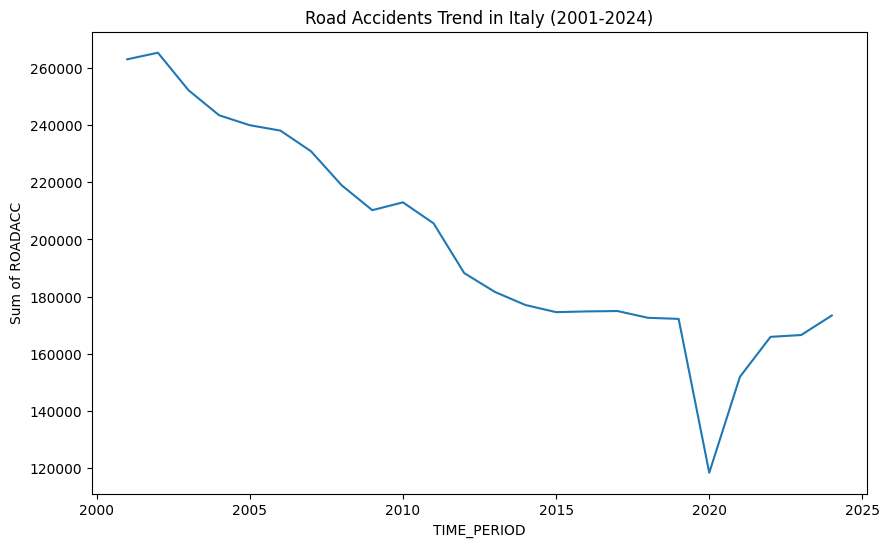

In [4]:
# group the df_merged_istat_data_comuni_name dataframe by 'TIME_PERIOD' and sum the 'ROADACC' column
df_merged_istat_data_comuni_name_groupby_time_period_sum_roadacc=df_merged_istat_data_comuni_name.groupby('TIME_PERIOD')['ROADACC'].sum().reset_index()

# visualize df_merged_istat_data_comuni_name_groupby_time_period_sum_roadacc using a line plot
plt.figure(figsize=(10,6))
plt.plot(df_merged_istat_data_comuni_name_groupby_time_period_sum_roadacc['TIME_PERIOD'], df_merged_istat_data_comuni_name_groupby_time_period_sum_roadacc['ROADACC'])
plt.xlabel('TIME_PERIOD')
plt.ylabel('Sum of ROADACC')
plt.title('Road Accidents Trend in Italy (2001-2024)')
plt.show()

## Top 10 Municipalities by Total Road Accidents
This chart shows the municipalities with the highest total number of road accidents from 2001 to 2024.
Large cities like Roma and Milano dominate, simply due to their size and population.
However, this metric alone is misleading without considering population and surface area, which is why we also analyze accidents per capita and per km².

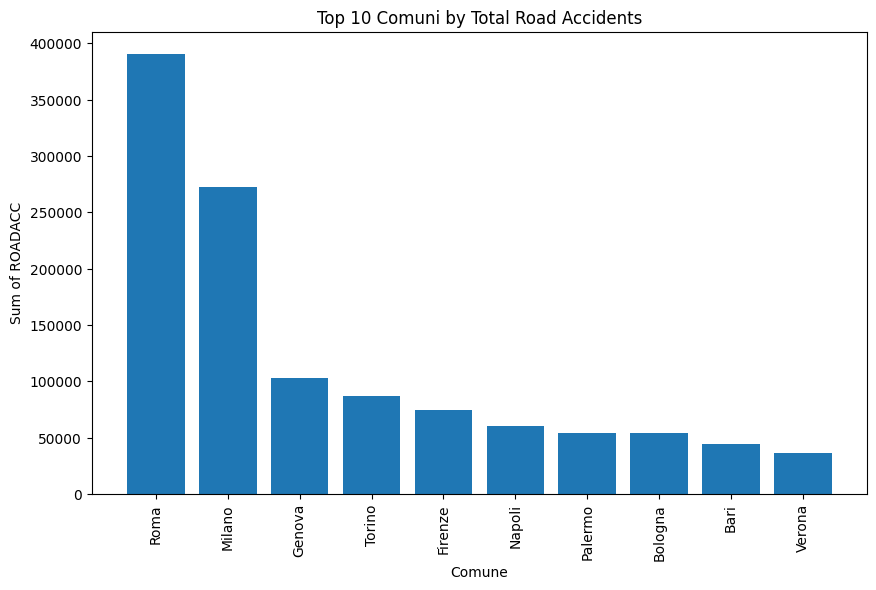

In [5]:
# group the df_merged_istat_data_comuni_name dataframe by 'Comune' and sum the 'ROADACC' column
df_merged_istat_data_comuni_name_groupby_top_10_Comune_sum_roadacc=df_merged_istat_data_comuni_name.groupby('Comune')['ROADACC'].sum().reset_index().sort_values(by='ROADACC', ascending=False).head(10)

# visualize df_merged_istat_data_comuni_name_groupby_top_10_Comune_sum_roadacc using a bar plot
plt.figure(figsize=(10,6))
plt.bar(df_merged_istat_data_comuni_name_groupby_top_10_Comune_sum_roadacc['Comune'], df_merged_istat_data_comuni_name_groupby_top_10_Comune_sum_roadacc['ROADACC'])
plt.xlabel('Comune')
plt.ylabel('Sum of ROADACC')
plt.title('Top 10 Comuni by Total Road Accidents')
plt.xticks(rotation=90)
plt.show()

## Top 10 Municipalities by Average Accidents per Capita
This chart shows the municipalities with the highest average annual accident rate relative to their population.
Small municipalities like Belforte Monferrato and Priero top the list, as they have few residents but high traffic volumes, especially during tourist seasons.

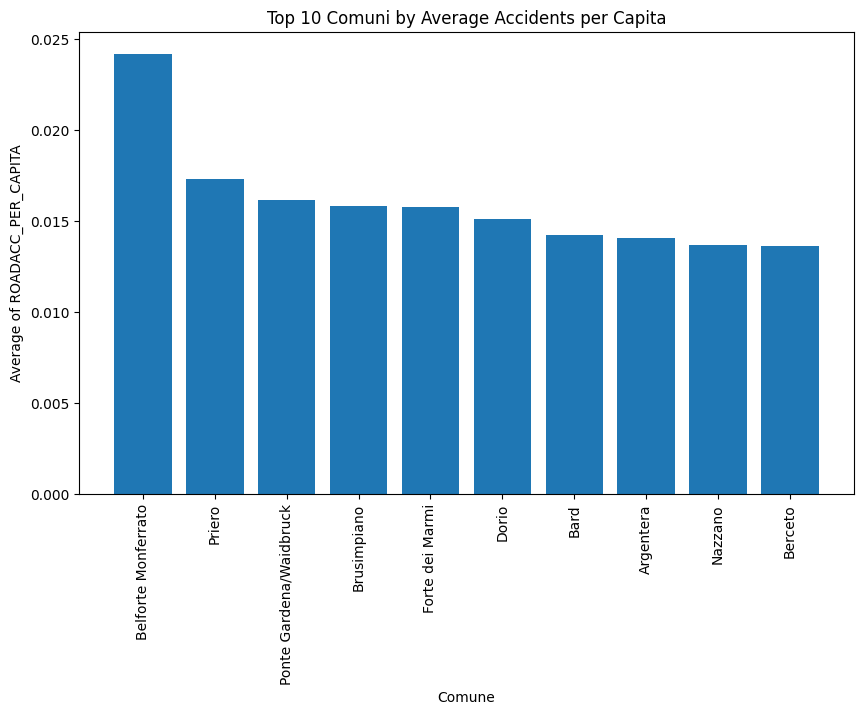

In [6]:
# group the df_merged_istat_data_comuni_name dataframe by 'Comune' and mean the 'ROADACC_PER_CAPITA' column
df_merged_istat_data_comuni_name_groupby_top_10_Comune_sum_roadacc_per_capita=df_merged_istat_data_comuni_name.groupby('Comune')['ROADACC_PER_CAPITA'].mean().reset_index().sort_values(by='ROADACC_PER_CAPITA', ascending=False).head(10)

# visualize df_merged_istat_data_comuni_name_groupby_top_10_Comune_sum_roadacc_per_capita using a bar plot
plt.figure(figsize=(10,6))
plt.bar(df_merged_istat_data_comuni_name_groupby_top_10_Comune_sum_roadacc_per_capita['Comune'], df_merged_istat_data_comuni_name_groupby_top_10_Comune_sum_roadacc_per_capita['ROADACC_PER_CAPITA'])
plt.xlabel('Comune')
plt.ylabel('Average of ROADACC_PER_CAPITA')
plt.title('Top 10 Comuni by Average Accidents per Capita')
plt.xticks(rotation=90)
plt.show()

## Top 10 Municipalities by Average Accidents per km²
This chart highlights the most dangerous municipalities in terms of accident density per square kilometer.
Milano leads by a wide margin, followed by densely urbanized municipalities in its metropolitan area.
This metric identifies areas where road infrastructure is under the most pressure.

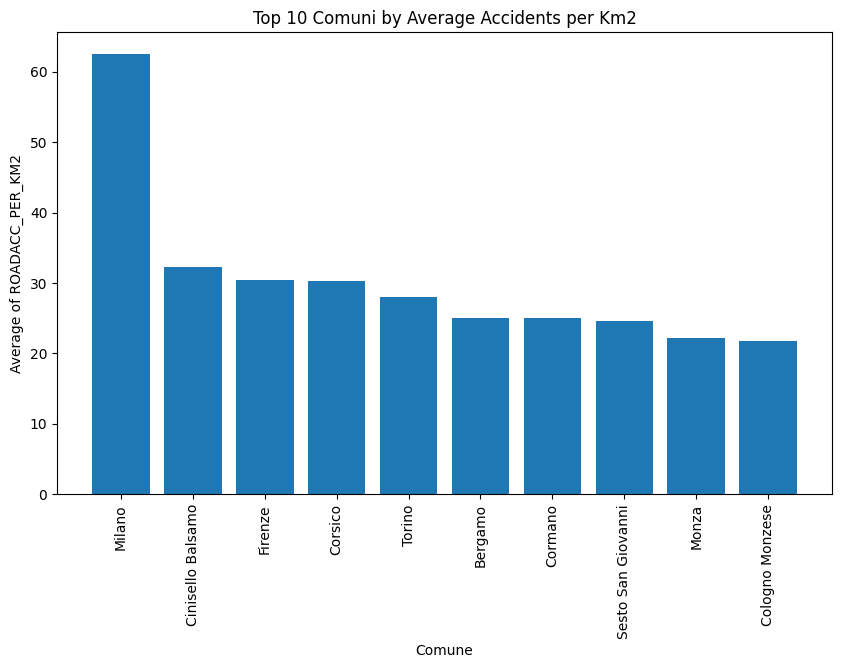

In [7]:
# group the df_merged_istat_data_comuni_name dataframe by 'Comune' and mean the 'ROADACC_PER_KM2' column
df_merged_istat_data_comuni_name_groupby_top_10_Comune_mean_roadacc_per_km2=df_merged_istat_data_comuni_name.groupby('Comune')['ROADACC_PER_KM2'].mean().reset_index().sort_values(by='ROADACC_PER_KM2', ascending=False).head(10)

# visualize df_merged_istat_data_comuni_name_groupby_top_10_Comune_mean_roadacc_per_km2 using a bar plot
plt.figure(figsize=(10,6))
plt.bar(df_merged_istat_data_comuni_name_groupby_top_10_Comune_mean_roadacc_per_km2['Comune'], df_merged_istat_data_comuni_name_groupby_top_10_Comune_mean_roadacc_per_km2['ROADACC_PER_KM2'])
plt.xlabel('Comune')
plt.ylabel('Average of ROADACC_PER_KM2')
plt.title('Top 10 Comuni by Average Accidents per Km2')
plt.xticks(rotation=90)
plt.show()